# Test de la Copule R-Vine Dynamique

Ce notebook teste l'implémentation de la copule R-Vine dynamique avec GJR-GARCH et innovations skewed-t.

## 1. Configuration et Préparation des Données

In [8]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

from src.copula import (
    fit_arma_garch_model,
    estimate_marginal_distribution,
    DynamicRVineCopula
)

# Configuration des plots avec style seaborn par défaut
sns.set_theme()
sns.set_style("whitegrid")
sns.set_palette("husl")

In [ ]:
# Chargement des données
def load_test_data():
    import pandas as pd
    import numpy as np
    from datetime import datetime
    
    # Définition des périodes
    periods = {
        'train': ('2018-01-02', '2022-12-28'),
        'validation': ('2023-01-02', '2023-12-28'),
        'test': ('2024-01-02', '2024-12-31')
    }
    
    # Charger les données
    all_data = pd.read_pickle('../processed_data/all_data.pkl')
    
    # Sélectionner quelques actifs pour les tests
    test_assets = list(all_data.columns.get_level_values(0).unique())[:5]
    test_data = all_data.loc[:, (test_assets, 'Close')]
    
    # Création des dates de rebalancement hebdomadaire
    rebalancing_dates = pd.date_range(
        start=periods['train'][0],
        end=periods['test'][1],
        freq='W-FRI'  # Rebalancement tous les vendredis
    )
    
    print("\nPériodes d'analyse:")
    for period_name, (start, end) in periods.items():
        period_data = test_data.loc[start:end]
        print(f"\n{period_name.capitalize()}:")
        print(f"- Début: {period_data.index[0].date()}")
        print(f"- Fin: {period_data.index[-1].date()}")
        print(f"- Nombre de jours: {len(period_data)}")
        
        # Nombre de dates de rebalancement dans la période
        rebal_in_period = rebalancing_dates[
            (rebalancing_dates >= period_data.index[0]) &
            (rebalancing_dates <= period_data.index[-1])
        ]
        print(f"- Nombre de rebalancements: {len(rebal_in_period)}")
    
    return test_data, test_assets, periods, rebalancing_dates

# Charger les données de test
test_data, test_assets, periods, rebalancing_dates = load_test_data()
print(f"\nActifs de test: {test_assets}")
print(f"\nFréquence de rebalancement: Hebdomadaire (chaque vendredi)")


Périodes d'analyse:

Train:
- Début: 2018-01-02
- Fin: 2022-12-28
- Nombre de jours: 1246

Validation:
- Début: 2023-01-02
- Fin: 2023-12-28
- Nombre de jours: 246

Test:
- Début: 2024-01-02
- Fin: 2024-12-31
- Nombre de jours: 249

Actifs de test: ['ABJC', 'BICC', 'BNBC', 'BOAB', 'BOABF']


## 2. Test du Modèle ARMA-GJR-GARCH

In [6]:
def test_garch_model(asset_returns):
    """Teste l'ajustement du modèle GJR-GARCH sur une série de rendements."""
    
    # Ajuster le modèle
    garch_fit = fit_arma_garch_model(asset_returns)
    
    if garch_fit is None:
        print("❌ Échec de l'ajustement du modèle GJR-GARCH")
        return None
    
    # Extraire les paramètres
    model = garch_fit['model']
    params = model.params
    
    # Afficher les résultats
    print("✅ Modèle GJR-GARCH ajusté avec succès")
    print("\nParamètres du modèle:")
    print(f"μ = {params['mu']:.4f}")
    print(f"ω = {params['omega']:.4f}")
    print(f"α = {params['alpha[1]']:.4f}")
    print(f"β = {params['beta[1]']:.4f}")
    print(f"γ = {params['gamma[1]']:.4f}")
    
    # Vérifier la stationnarité
    stationarity = params['alpha[1]'] + params['beta[1]'] + (params['gamma[1]'] / 2)
    status = "✅" if stationarity < 0.999 else "⚠️" if stationarity < 1.01 else "❌"
    status_text = {
        "✅": "stable",
        "⚠️": "proche limite",
        "❌": "instable"
    }[status]
    print(f"\nTest de stationnarité: {stationarity:.4f} {status} ({status_text})")
    
    return garch_fit

# Tester sur le premier actif
test_asset = test_assets[0]
prices = test_data[test_asset]
returns = np.log(prices / prices.shift(1)).dropna()
returns.name = test_asset

print(f"Test du modèle GJR-GARCH sur {test_asset}\n")
garch_result = test_garch_model(returns)

/opt/miniconda3/envs/finrl_env/lib/python3.10/site-packages/arch/univariate/base.py:768: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
[INFO] ACCEPTÉ [ABJC]: Modèle ajusté avec succès.


Test du modèle GJR-GARCH sur ABJC

✅ Modèle GJR-GARCH ajusté avec succès

Paramètres du modèle:
μ = 0.0002
ω = 0.0000
α = 0.0500
β = 0.9250
γ = 0.0100

Test de stationnarité: 0.9800 ✅ (stable)


### Analyse des Résidus Standardisés

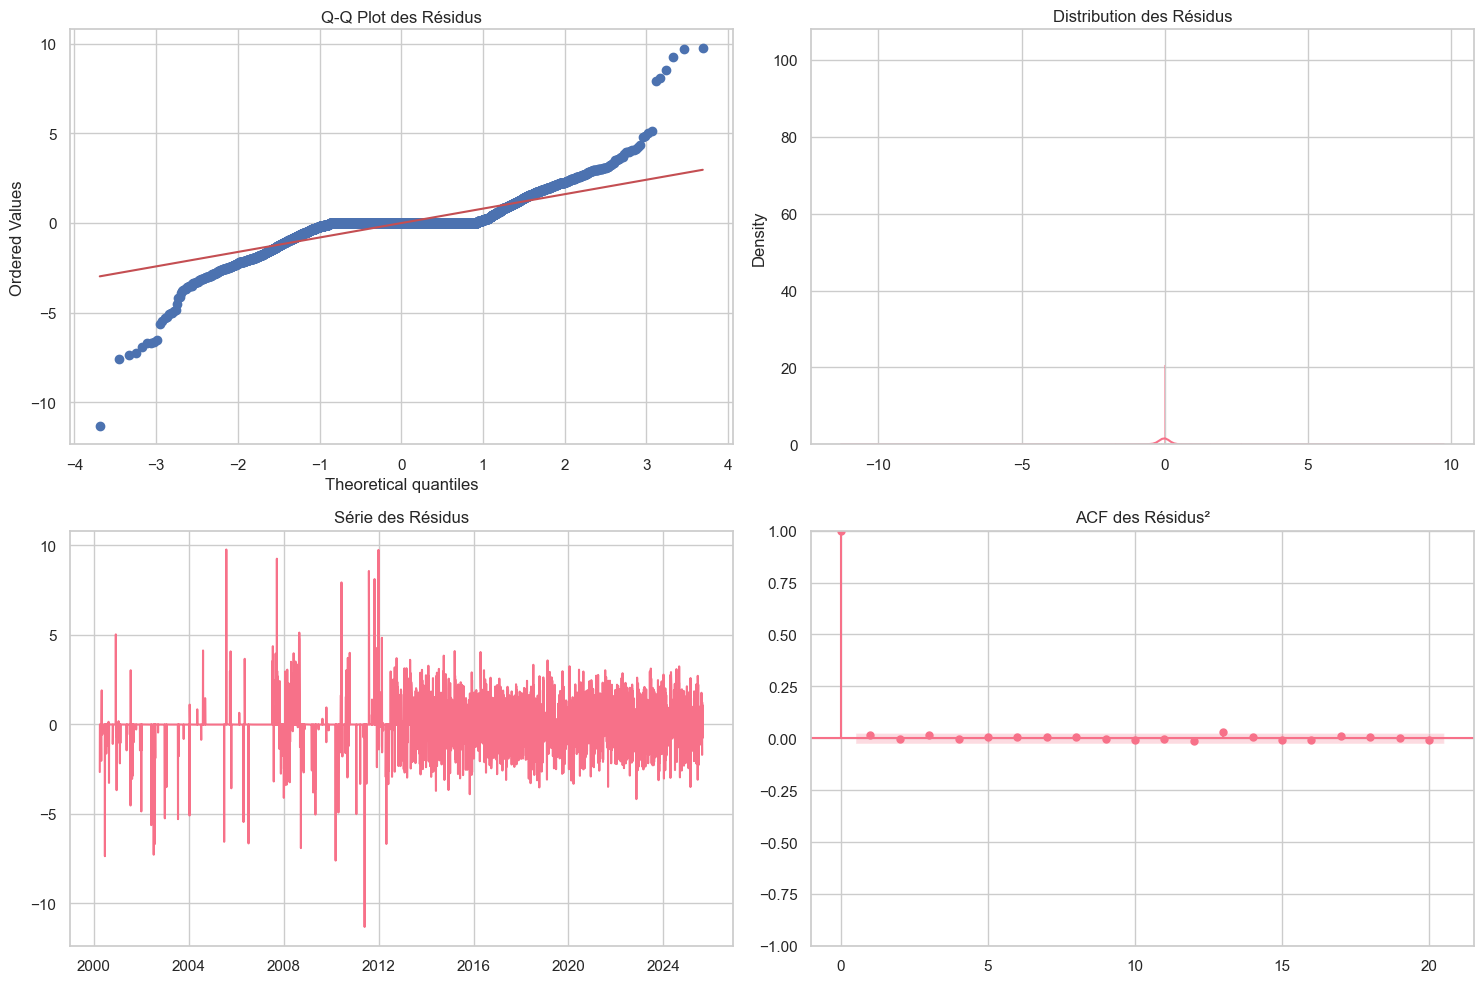

In [7]:
def plot_residuals_analysis(garch_fit):
    """Analyse graphique des résidus standardisés."""
    if garch_fit is None:
        return
    
    std_resid = garch_fit['std_resid']
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # QQ-Plot
    stats.probplot(std_resid, dist="norm", plot=axes[0,0])
    axes[0,0].set_title('Q-Q Plot des Résidus')
    
    # Histogramme
    sns.histplot(std_resid, stat='density', kde=True, ax=axes[0,1])
    axes[0,1].set_title('Distribution des Résidus')
    
    # Série temporelle
    axes[1,0].plot(std_resid)
    axes[1,0].set_title('Série des Résidus')
    
    # ACF des résidus au carré
    from statsmodels.graphics.tsaplots import plot_acf
    plot_acf(std_resid**2, lags=20, ax=axes[1,1])
    axes[1,1].set_title('ACF des Résidus²')
    
    plt.tight_layout()
    
plot_residuals_analysis(garch_result)

## 3. Test de l'Estimation des Distributions Marginales

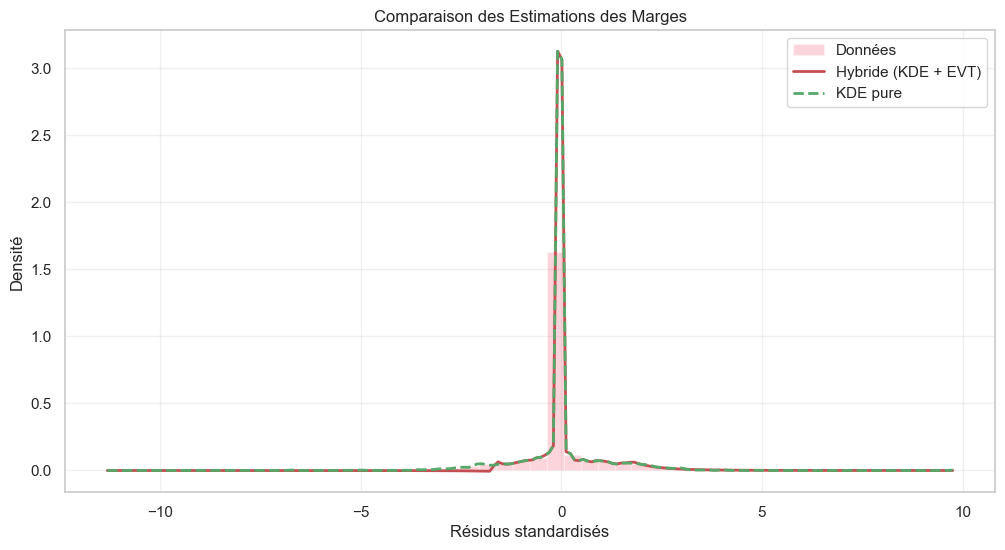

In [15]:
def compare_marginal_distributions(garch_fit):
    """Compare les différentes approches d'estimation des marges."""
    if garch_fit is None:
        return
    
    std_resid = garch_fit['std_resid']
    
    # Estimation hybride (KDE + EVT)
    hybrid_dist = estimate_marginal_distribution(std_resid, hybrid=True)
    
    # Estimation KDE pure
    kde_dist = estimate_marginal_distribution(std_resid, hybrid=False)
    
    # Points d'évaluation
    x = np.linspace(std_resid.min(), std_resid.max(), 200)
    
    # Calcul des densités
    hybrid_density = np.gradient(hybrid_dist['cdf'](x), x)
    kde_density = np.gradient(kde_dist['cdf'](x), x)
    
    # Plot
    plt.figure(figsize=(12, 6))
    
    # Histogramme des données
    plt.hist(std_resid, bins=50, density=True, alpha=0.3, label='Données')
    
    # Densités estimées
    plt.plot(x, hybrid_density, 'r-', lw=2, label='Hybride (KDE + EVT)')
    plt.plot(x, kde_density, 'g--', lw=2, label='KDE pure')
    
    plt.title('Comparaison des Estimations des Marges')
    plt.xlabel('Résidus standardisés')
    plt.ylabel('Densité')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
compare_marginal_distributions(garch_result)

## 4. Test de la Copule R-Vine Dynamique

In [ ]:
# Initialiser la copule
from src.copula import DynamicRVineCopula  # Import depuis le fichier original
copula = DynamicRVineCopula(test_data, n_simulations=1000)

def test_copula_on_period(copula, start_date, end_date, rebalancing_dates):
    """Teste la copule sur une période spécifique avec rebalancement hebdomadaire."""
    
    # Filtrer les dates de rebalancement dans la période
    period_rebalancing = rebalancing_dates[
        (rebalancing_dates >= pd.Timestamp(start_date)) &
        (rebalancing_dates <= pd.Timestamp(end_date))
    ]
    
    results = []
    for rebal_date in period_rebalancing:
        print(f"\nTest pour la date de rebalancement: {rebal_date.date()}")
        
        try:
            # Simuler les rendements pour la semaine suivante
            period_returns, daily_returns, valid_assets = copula.simulate_period_returns(
                test_assets,
                rebal_date,
                period_days=5,  # Une semaine de trading
                window_weeks=52  # Fenêtre d'un an
            )
            
            results.append({
                'date': rebal_date,
                'returns': period_returns,
                'daily_returns': daily_returns,
                'valid_assets': valid_assets
            })
            
            print(f"✅ Simulation réussie - {len(valid_assets)} actifs valides")
            
        except Exception as e:
            print(f"❌ Erreur lors de la simulation: {str(e)}")
    
    return results

# Tester sur la période de validation
print("Test de la copule sur la période de validation")
validation_results = test_copula_on_period(
    copula,
    periods['validation'][0],
    periods['validation'][1],
    rebalancing_dates
)

[INFO] 🌀 AJUSTEMENT COPULE : 2024-08-29 -> 2025-08-28
[INFO] ACCEPTÉ [('ABJC', 'Close')]: Modèle ajusté avec succès.
[INFO] ACCEPTÉ [('ABJC', 'Close')]: Modèle ajusté avec succès.
[INFO] ACCEPTÉ [('BOABF', 'Close')]: Modèle ajusté avec succès.
[INFO] ACCEPTÉ [('BOABF', 'Close')]: Modèle ajusté avec succès.
[INFO] ACCEPTÉ [('BOAB', 'Close')]: Modèle ajusté avec succès.
[INFO] ACCEPTÉ [('BNBC', 'Close')]: Modèle ajusté avec succès.
[INFO] ACCEPTÉ [('BICC', 'Close')]: Modèle ajusté avec succès.
[INFO] ACCEPTÉ [('BOAB', 'Close')]: Modèle ajusté avec succès.
[INFO] ACCEPTÉ [('BNBC', 'Close')]: Modèle ajusté avec succès.
[INFO] ACCEPTÉ [('BICC', 'Close')]: Modèle ajusté avec succès.
[INFO] Copule R-Vine ajustée avec 5 actifs (approche hybride).
[INFO] Copule R-Vine ajustée avec 5 actifs (approche hybride).
[INFO] 🔬 Simulation des rendements journaliers (copule hybride)
[INFO] ABJC: Rendements simulés (moyenne=+0.08%, std=+2.53%)
[INFO] BOABF: Rendements simulés (moyenne=+0.15%, std=+1.60%)
[

Statistiques des rendements simulés:


,Moyenne,Std,Skew,Kurt
ABJC,0.000499,0.005627,0.043915,0.316242
BOABF,0.021182,0.003309,5.180672,118.105865
BOAB,0.005507,0.007700,-0.066474,0.062376
BNBC,0.002514,0.003622,0.059676,-0.099556
BICC,0.001389,0.003506,0.195405,0.212400


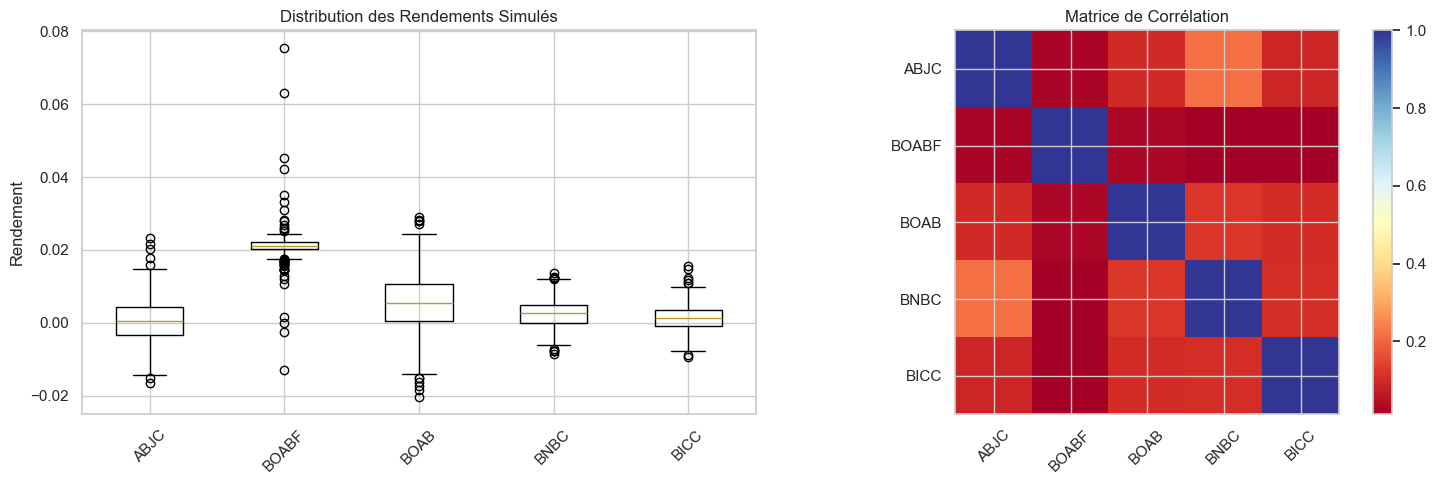

In [17]:
def plot_simulation_results(period_returns, valid_assets):
    """Visualise les résultats de la simulation."""
    
    # Statistiques des rendements simulés
    stats_df = pd.DataFrame({
        'Moyenne': np.mean(period_returns, axis=0),
        'Std': np.std(period_returns, axis=0),
        'Skew': stats.skew(period_returns, axis=0),
        'Kurt': stats.kurtosis(period_returns, axis=0)
    }, index=valid_assets)
    
    print("Statistiques des rendements simulés:")
    display(stats_df)
    
    # Visualisation des distributions
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Boxplots
    axes[0].boxplot([period_returns[:,i] for i in range(len(valid_assets))])
    axes[0].set_xticklabels(valid_assets, rotation=45)
    axes[0].set_title('Distribution des Rendements Simulés')
    axes[0].set_ylabel('Rendement')
    
    # Matrice de corrélation
    corr = np.corrcoef(period_returns.T)
    im = axes[1].imshow(corr, cmap='RdYlBu')
    plt.colorbar(im, ax=axes[1])
    axes[1].set_xticks(range(len(valid_assets)))
    axes[1].set_yticks(range(len(valid_assets)))
    axes[1].set_xticklabels(valid_assets, rotation=45)
    axes[1].set_yticklabels(valid_assets)
    axes[1].set_title('Matrice de Corrélation')
    
    plt.tight_layout()

plot_simulation_results(period_returns, valid_assets)

## 5. Tests de Performance et Gestion des Erreurs

In [18]:
def stress_test_copula():
    """Tests de stress de la copule avec différents scénarios."""
    
    print("1. Test avec données manquantes")
    corrupted_data = test_data.copy()
    corrupted_data.iloc[10:20] = np.nan
    copula_corrupt = DynamicRVineCopula(corrupted_data)
    try:
        returns_corrupt = copula_corrupt.simulate_period_returns(
            test_assets[:2],
            current_date,
            5
        )
        print("✅ Gestion correcte des NaN")
    except Exception as e:
        print(f"❌ Erreur avec NaN: {str(e)[:100]}")
    
    print("\n2. Test avec fenêtre courte")
    try:
        returns_short = copula.simulate_period_returns(
            test_assets,
            current_date,
            5,
            window_weeks=4
        )
        print("✅ Gestion correcte de la fenêtre courte")
    except Exception as e:
        print(f"❌ Erreur avec fenêtre courte: {str(e)[:100]}")
    
    print("\n3. Test avec actif invalide")
    try:
        returns_invalid = copula.simulate_period_returns(
            test_assets + ['INVALID'],
            current_date,
            5
        )
        print("✅ Gestion correcte de l'actif invalide")
    except Exception as e:
        print(f"❌ Erreur avec actif invalide: {str(e)[:100]}")

stress_test_copula()

[INFO] 🌀 AJUSTEMENT COPULE : 2024-08-29 -> 2025-08-28
[INFO] ACCEPTÉ [('ABJC', 'Close')]: Modèle ajusté avec succès.
[INFO] ACCEPTÉ [('ABJC', 'Close')]: Modèle ajusté avec succès.


1. Test avec données manquantes


[INFO] ACCEPTÉ [('BICC', 'Close')]: Modèle ajusté avec succès.
[INFO] Copule R-Vine ajustée avec 2 actifs (approche hybride).
[INFO] 🔬 Simulation des rendements journaliers (copule hybride)
[INFO] ABJC: Rendements simulés (moyenne=+0.14%, std=+2.47%)
[INFO] BICC: Rendements simulés (moyenne=+2.16%, std=+4.11%)
[INFO] Simulation réussie pour 2/2 actifs (copule hybride).
[INFO] Copule R-Vine ajustée avec 2 actifs (approche hybride).
[INFO] 🔬 Simulation des rendements journaliers (copule hybride)
[INFO] ABJC: Rendements simulés (moyenne=+0.14%, std=+2.47%)
[INFO] BICC: Rendements simulés (moyenne=+2.16%, std=+4.11%)
[INFO] Simulation réussie pour 2/2 actifs (copule hybride).
[INFO] 🔬 Simulation des rendements journaliers (copule hybride)
[INFO] ABJC: Rendements simulés (moyenne=+0.07%, std=+2.49%)
[INFO] BOABF: Rendements simulés (moyenne=+0.16%, std=+1.61%)
[INFO] BOAB: Rendements simulés (moyenne=+0.21%, std=+1.61%)
[INFO] BNBC: Rendements simulés (moyenne=+0.62%, std=+3.38%)
[INFO] BIC

✅ Gestion correcte des NaN

2. Test avec fenêtre courte
✅ Gestion correcte de la fenêtre courte

3. Test avec actif invalide


[INFO] ACCEPTÉ [('ABJC', 'Close')]: Modèle ajusté avec succès.
[INFO] ACCEPTÉ [('BOABF', 'Close')]: Modèle ajusté avec succès.
[INFO] ACCEPTÉ [('BOAB', 'Close')]: Modèle ajusté avec succès.
[INFO] ACCEPTÉ [('BICC', 'Close')]: Modèle ajusté avec succès.
[INFO] ACCEPTÉ [('BNBC', 'Close')]: Modèle ajusté avec succès.
[INFO] ACCEPTÉ [('BOABF', 'Close')]: Modèle ajusté avec succès.
[INFO] ACCEPTÉ [('BOAB', 'Close')]: Modèle ajusté avec succès.
[INFO] ACCEPTÉ [('BICC', 'Close')]: Modèle ajusté avec succès.
[INFO] ACCEPTÉ [('BNBC', 'Close')]: Modèle ajusté avec succès.
[INFO] Copule R-Vine ajustée avec 5 actifs (approche hybride).
[INFO] 🔬 Simulation des rendements journaliers (copule hybride)
[INFO] Copule R-Vine ajustée avec 5 actifs (approche hybride).
[INFO] 🔬 Simulation des rendements journaliers (copule hybride)
[INFO] ABJC: Rendements simulés (moyenne=+0.07%, std=+2.47%)
[INFO] BOABF: Rendements simulés (moyenne=+0.19%, std=+1.63%)
[INFO] BOAB: Rendements simulés (moyenne=+0.29%, std=+

✅ Gestion correcte de l'actif invalide


## 6. Visualisation Avancée des Résultats

## 7. Tests Avancés de la Copule

Cette section ajoute des tests supplémentaires pour valider la robustesse de la copule :
1. Stabilité temporelle
2. Goodness-of-fit
3. Benchmark vs copule gaussienne

[INFO] 🌀 AJUSTEMENT COPULE : 2021-08-29 -> 2022-08-28
[INFO] ACCEPTÉ [('BICC', 'Close')]: Modèle ajusté avec succès.
[INFO] ACCEPTÉ [('BOABF', 'Close')]: Modèle ajusté avec succès.
[WARNING] ATTENTION [('ABJC', 'Close')]: Proche de l'instabilité (somme GJR-GARCH=1.0000).
[INFO] ACCEPTÉ [('BOAB', 'Close')]: Modèle ajusté avec succès.
[WARNING] ATTENTION [('BNBC', 'Close')]: Proche de l'instabilité (somme GJR-GARCH=1.0000).
[INFO] ACCEPTÉ [('ABJC', 'Close')]: Modèle ajusté avec succès.
[INFO] ACCEPTÉ [('BNBC', 'Close')]: Modèle ajusté avec succès.
[INFO] Copule R-Vine ajustée avec 5 actifs (approche hybride).
[INFO] 🔬 Simulation des rendements journaliers (copule hybride)
[INFO] BICC: Rendements simulés (moyenne=+0.26%, std=+2.41%)
[INFO] BOABF: Rendements simulés (moyenne=+0.28%, std=+0.61%)
[INFO] BOAB: Rendements simulés (moyenne=+0.81%, std=+0.58%)
[INFO] ABJC: Rendements simulés (moyenne=+0.33%, std=+2.31%)
[INFO] BNBC: Rendements simulés (moyenne=+0.33%, std=+1.53%)
[INFO] Simulati

Erreur pour la date 2023-08-27 00:00:00: Length of values (5) does not match length of index (4)


[INFO] ACCEPTÉ [('ABJC', 'Close')]: Modèle ajusté avec succès.
[INFO] ACCEPTÉ [('BICC', 'Close')]: Modèle ajusté avec succès.
[WARNING] ATTENTION [('BOAB', 'Close')]: Proche de l'instabilité (somme GJR-GARCH=1.0000).
[WARNING] ATTENTION [('BNBC', 'Close')]: Proche de l'instabilité (somme GJR-GARCH=1.0000).
[INFO] ACCEPTÉ [('BOAB', 'Close')]: Modèle ajusté avec succès.
[INFO] ACCEPTÉ [('BNBC', 'Close')]: Modèle ajusté avec succès.
[INFO] Copule R-Vine ajustée avec 5 actifs (approche hybride).
[INFO] 🔬 Simulation des rendements journaliers (copule hybride)
[INFO] BOABF: Rendements simulés (moyenne=+0.20%, std=+1.61%)
[INFO] ABJC: Rendements simulés (moyenne=+0.55%, std=+2.57%)
[INFO] BICC: Rendements simulés (moyenne=+0.75%, std=+0.63%)
[INFO] BOAB: Rendements simulés (moyenne=-58.12%, std=+19.69%)
[INFO] BNBC: Rendements simulés (moyenne=+0.06%, std=+2.33%)
[INFO] Simulation réussie pour 5/5 actifs (copule hybride).
[INFO] 🌀 AJUSTEMENT COPULE : 2024-08-25 -> 2025-08-24
[INFO] ACCEPTÉ [(

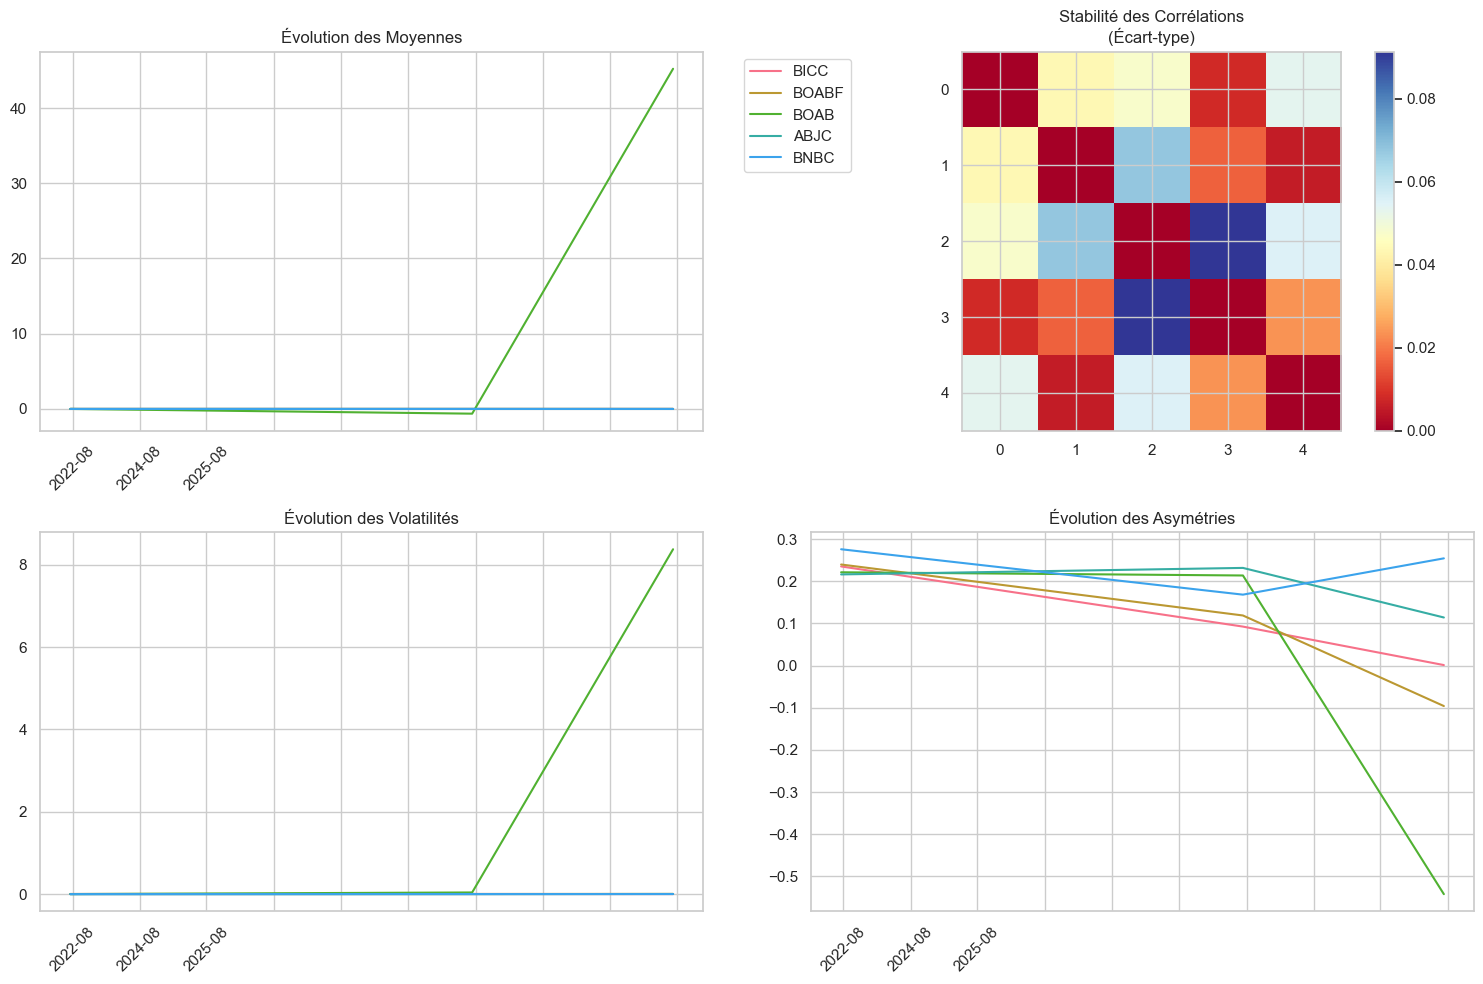

In [21]:
def test_temporal_stability(copula, test_data, test_assets, window_weeks=52, n_windows=4):
    """Test de la stabilité temporelle de la copule."""
    end_dates = pd.date_range(
        end=test_data.index[-1],
        periods=n_windows,
        freq=f'{window_weeks}W'
    )
    
    results = []
    for date in end_dates:
        try:
            # Simulation sur chaque fenêtre
            period_returns, _, valid_assets = copula.simulate_period_returns(
                test_assets,
                date,
                period_days=20,
                window_weeks=window_weeks
            )
            
            # Calcul des statistiques
            stats_df = pd.DataFrame({
                'Mean': np.mean(period_returns, axis=0),
                'Std': np.std(period_returns, axis=0),
                'Skew': stats.skew(period_returns, axis=0),
                'Kurt': stats.kurtosis(period_returns, axis=0)
            }, index=valid_assets)
            
            results.append({
                'date': date,
                'stats': stats_df,
                'corr': np.corrcoef(period_returns.T)
            })
            
        except Exception as e:
            print(f"Erreur pour la date {date}: {str(e)[:100]}")
    
    return results

# Lancer le test de stabilité
stability_results = test_temporal_stability(copula, test_data, test_assets)

# Visualisation des résultats
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot de l'évolution des moyennes
means = pd.DataFrame([
    {asset: res['stats'].loc[asset, 'Mean'] 
     for asset in res['stats'].index}
    for res in stability_results
], index=[res['date'] for res in stability_results])

axes[0,0].plot(means)
axes[0,0].set_title("Évolution des Moyennes")
axes[0,0].set_xticklabels([d.strftime('%Y-%m') for d in means.index], rotation=45)
axes[0,0].legend(means.columns, bbox_to_anchor=(1.05, 1))

# Plot de l'évolution des corrélations
corr_evol = np.array([res['corr'] for res in stability_results])
im = axes[0,1].imshow(np.std(corr_evol, axis=0), cmap='RdYlBu')
plt.colorbar(im, ax=axes[0,1])
axes[0,1].set_title("Stabilité des Corrélations\n(Écart-type)")

# Plot des volatilités
stds = pd.DataFrame([
    {asset: res['stats'].loc[asset, 'Std']
     for asset in res['stats'].index}
    for res in stability_results
], index=[res['date'] for res in stability_results])

axes[1,0].plot(stds)
axes[1,0].set_title("Évolution des Volatilités")
axes[1,0].set_xticklabels([d.strftime('%Y-%m') for d in stds.index], rotation=45)

# Plot des skewness
skews = pd.DataFrame([
    {asset: res['stats'].loc[asset, 'Skew']
     for asset in res['stats'].index}
    for res in stability_results
], index=[res['date'] for res in stability_results])

axes[1,1].plot(skews)
axes[1,1].set_title("Évolution des Asymétries")
axes[1,1].set_xticklabels([d.strftime('%Y-%m') for d in skews.index], rotation=45)

plt.tight_layout()


Comparaison avec une copule gaussienne :
--------------------------------------------------


,R-Vine,Gaussienne
Skewness,1.109228,0.054247
Kurtosis,23.719465,0.077018
Max Corr,0.213337,0.250403
Min Corr,0.000000,0.000000


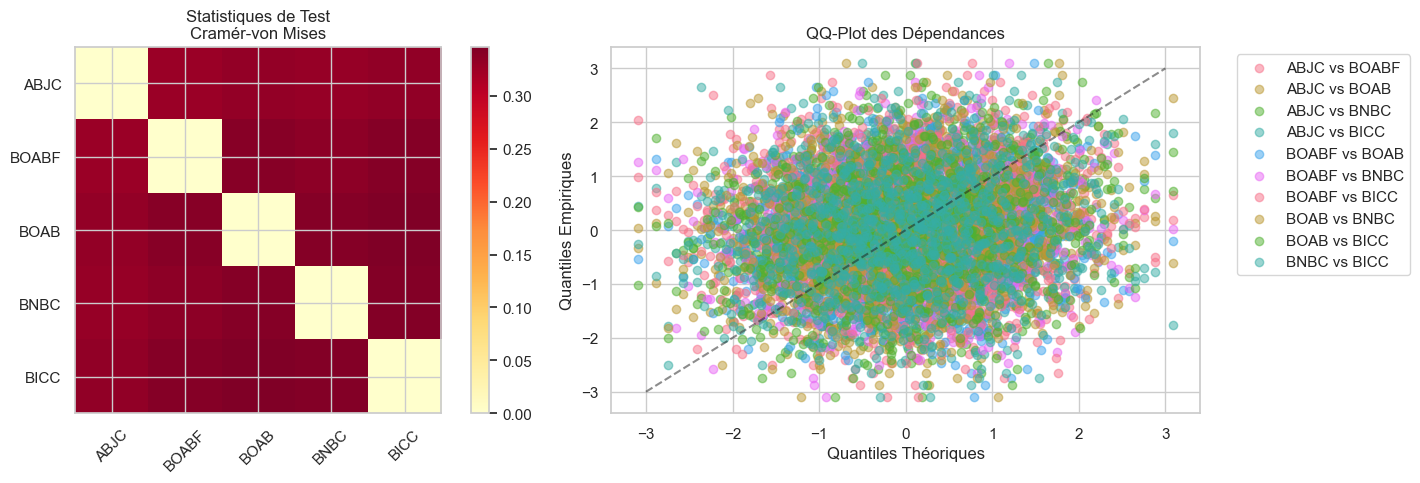

In [22]:
def test_goodness_of_fit(period_returns, valid_assets):
    """Test de l'adéquation de la copule aux données."""
    
    # Calcul des rangs empiriques
    ranks = pd.DataFrame(
        data=stats.rankdata(period_returns, axis=0) / (len(period_returns) + 1),
        columns=valid_assets
    )
    
    # Test de Cramér-von Mises pour l'indépendance
    def cramer_von_mises_test(x, y):
        n = len(x)
        empirical = np.column_stack([x, y])
        independent = np.column_stack([np.sort(x), np.sort(y)])
        stat = np.mean(np.sum((empirical - independent) ** 2, axis=1))
        return stat
    
    # Matrice des statistiques de test
    n_assets = len(valid_assets)
    test_matrix = np.zeros((n_assets, n_assets))
    p_values = np.zeros((n_assets, n_assets))
    
    for i in range(n_assets):
        for j in range(i+1, n_assets):
            stat = cramer_von_mises_test(ranks.iloc[:,i], ranks.iloc[:,j])
            test_matrix[i,j] = test_matrix[j,i] = stat
    
    # Visualisation
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Heatmap des statistiques de test
    im = axes[0].imshow(test_matrix, cmap='YlOrRd')
    plt.colorbar(im, ax=axes[0])
    axes[0].set_title("Statistiques de Test\nCramér-von Mises")
    axes[0].set_xticks(range(n_assets))
    axes[0].set_yticks(range(n_assets))
    axes[0].set_xticklabels(valid_assets, rotation=45)
    axes[0].set_yticklabels(valid_assets)
    
    # QQ-plot des dépendances
    for i in range(n_assets):
        for j in range(i+1, n_assets):
            axes[1].scatter(
                stats.norm.ppf(ranks.iloc[:,i]),
                stats.norm.ppf(ranks.iloc[:,j]),
                alpha=0.5,
                label=f'{valid_assets[i]} vs {valid_assets[j]}'
            )
    
    axes[1].plot([-3,3], [-3,3], 'k--', alpha=0.5)
    axes[1].set_title("QQ-Plot des Dépendances")
    axes[1].set_xlabel("Quantiles Théoriques")
    axes[1].set_ylabel("Quantiles Empiriques")
    axes[1].legend(bbox_to_anchor=(1.05, 1))
    
    plt.tight_layout()
    
    return test_matrix

# Test de goodness-of-fit
gof_stats = test_goodness_of_fit(period_returns, valid_assets)

# Comparaison avec une copule gaussienne simple
print("\nComparaison avec une copule gaussienne :")
print("-" * 50)

# Simulation depuis une copule gaussienne
n_sims = period_returns.shape[0]
n_assets = len(valid_assets)

# Matrice de corrélation empirique
corr = np.corrcoef(period_returns.T)

# Simulation
rng = np.random.default_rng(42)
gaussian_returns = rng.multivariate_normal(
    mean=np.zeros(n_assets),
    cov=corr,
    size=n_sims
)

# Statistiques comparatives
stats_comparison = pd.DataFrame({
    'R-Vine': {
        'Skewness': np.mean(np.abs(stats.skew(period_returns, axis=0))),
        'Kurtosis': np.mean(stats.kurtosis(period_returns, axis=0)),
        'Max Corr': np.max(np.triu(corr, k=1)),
        'Min Corr': np.min(np.triu(corr, k=1))
    },
    'Gaussienne': {
        'Skewness': np.mean(np.abs(stats.skew(gaussian_returns, axis=0))),
        'Kurtosis': np.mean(stats.kurtosis(gaussian_returns, axis=0)),
        'Max Corr': np.max(np.triu(np.corrcoef(gaussian_returns.T), k=1)),
        'Min Corr': np.min(np.triu(np.corrcoef(gaussian_returns.T), k=1))
    }
})

display(stats_comparison)

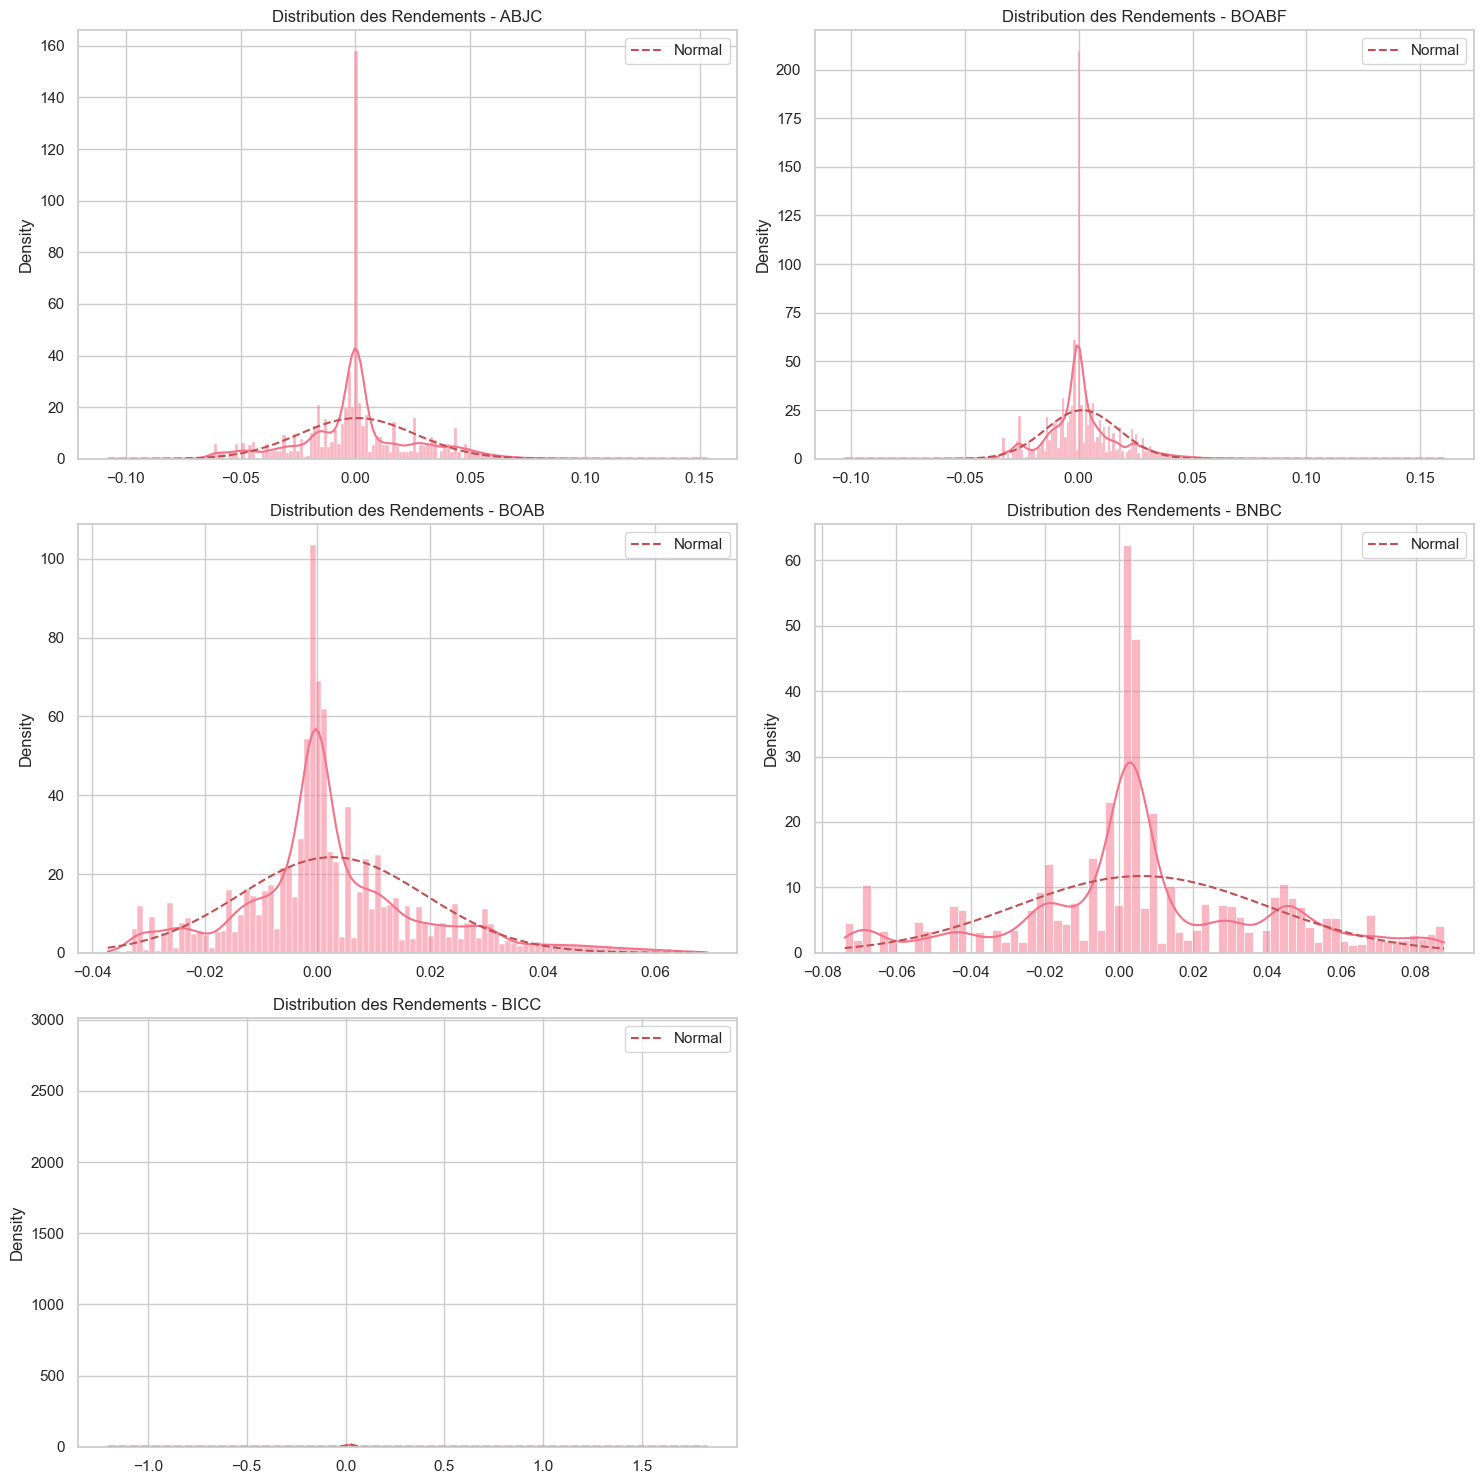

In [23]:
def plot_advanced_diagnostics(daily_returns, valid_assets):
    """Diagnostics avancés des simulations."""
    
    n_assets = len(valid_assets)
    fig = plt.figure(figsize=(15, 5*((n_assets+1)//2)))
    
    # Plot pour chaque actif
    for i, asset in enumerate(valid_assets):
        ax = fig.add_subplot((n_assets+1)//2, 2, i+1)
        
        # Histogramme des rendements journaliers
        sns.histplot(daily_returns[:,i], stat='density', kde=True, ax=ax)
        
        # Ajout d'une distribution normale pour comparaison
        x = np.linspace(daily_returns[:,i].min(), daily_returns[:,i].max(), 100)
        ax.plot(x, stats.norm.pdf(x, daily_returns[:,i].mean(), daily_returns[:,i].std()),
                'r--', label='Normal')
        
        ax.set_title(f'Distribution des Rendements - {asset}')
        ax.legend()
    
    plt.tight_layout()

plot_advanced_diagnostics(daily_returns, valid_assets)

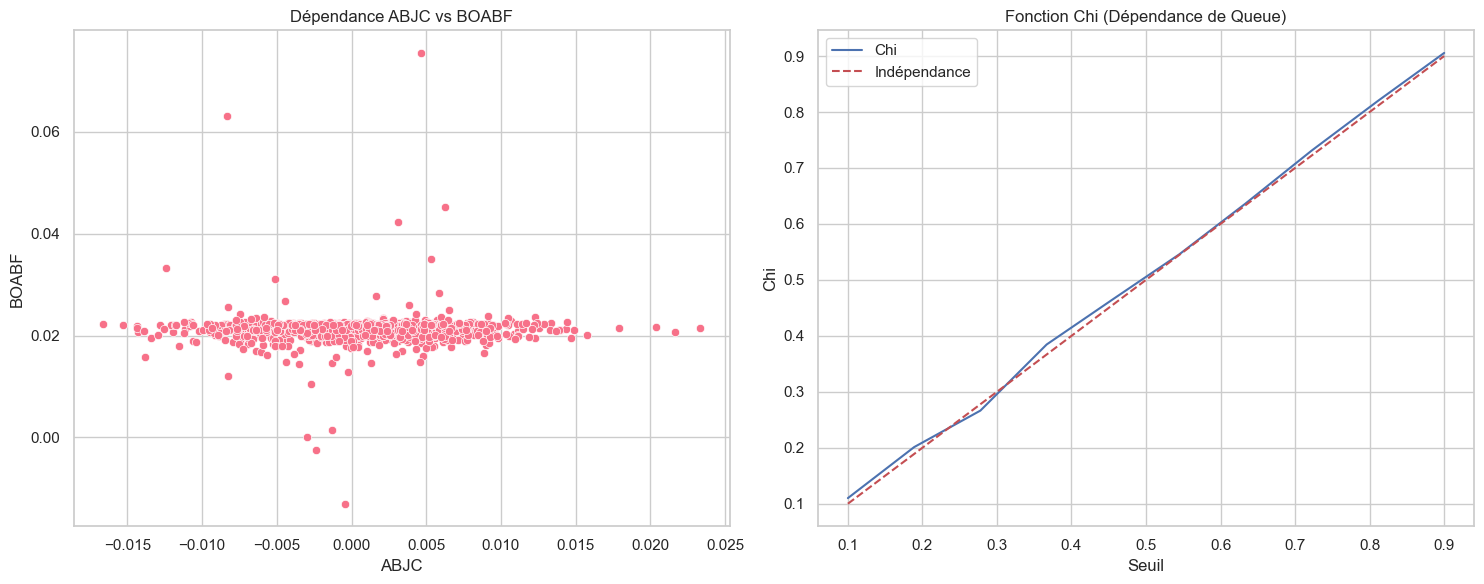

In [20]:
def plot_tail_dependence(period_returns, valid_assets):
    """Analyse de la dépendance de queue entre les actifs."""
    
    n_assets = len(valid_assets)
    if n_assets < 2:
        return
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Scatter plot des deux premiers actifs
    sns.scatterplot(x=period_returns[:,0], y=period_returns[:,1], ax=axes[0])
    axes[0].set_title(f'Dépendance {valid_assets[0]} vs {valid_assets[1]}')
    axes[0].set_xlabel(valid_assets[0])
    axes[0].set_ylabel(valid_assets[1])
    
    # Chi-plot pour la dépendance de queue
    ranks0 = stats.rankdata(period_returns[:,0]) / len(period_returns)
    ranks1 = stats.rankdata(period_returns[:,1]) / len(period_returns)
    
    chi = np.zeros(10)
    u = np.linspace(0.1, 0.9, 10)
    
    for i, threshold in enumerate(u):
        chi[i] = np.mean((ranks0 <= threshold) & (ranks1 <= threshold)) / threshold
    
    axes[1].plot(u, chi, 'b-', label='Chi')
    axes[1].plot(u, u, 'r--', label='Indépendance')
    axes[1].set_title('Fonction Chi (Dépendance de Queue)')
    axes[1].set_xlabel('Seuil')
    axes[1].set_ylabel('Chi')
    axes[1].legend()
    
    plt.tight_layout()

plot_tail_dependence(period_returns, valid_assets)